# 2026 World Cup Final Predictor — Part 3: The Verdict

**Spain vs Argentina — who lifts the trophy?**

We combine three independent lenses, then resolve the fact that a final *cannot end in a draw* (extra time, then penalties):

1. **Elo expectancy** — win probability implied by the ratings built in notebook 02
2. **Poisson + Monte Carlo** — simulate the final 200,000 times, goal by goal, including extra time and penalty shootouts
3. **Machine learning** — the gradient boosting model from notebook 02

Finally we average the three into an ensemble verdict.

In [1]:
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (11, 4.5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})

SPAIN, ARG = 'Spain', 'Argentina'
COLORS = {SPAIN: '#C60B1E', ARG: '#75AADB'}
rng = np.random.default_rng(42)

results = pd.read_csv('../data/results.csv', parse_dates=['date'])
played = results.dropna(subset=['home_score', 'away_score']).copy()
elo = pd.read_csv('../data/current_elo.csv', index_col=0)['elo']
print(f"Elo — Spain: {elo[SPAIN]:.0f}   Argentina: {elo[ARG]:.0f}   (gap: {elo[SPAIN]-elo[ARG]:+.0f})")

Elo — Spain: 2300   Argentina: 2273   (gap: +27)


## Lens 1 — Elo expectancy

The standard Elo formula gives the *expected score* of a match (win = 1, draw = 0.5). On neutral ground there is no home-advantage adjustment. Because a drawn final is decided by extra time and penalties — close to a coin flip between evenly-matched sides — the Elo expectancy is a reasonable direct estimate of the probability of lifting the trophy.

In [2]:
p_elo_spain = 1 / (1 + 10 ** ((elo[ARG] - elo[SPAIN]) / 400))
print(f"Elo expectancy — Spain: {p_elo_spain:.1%}   Argentina: {1-p_elo_spain:.1%}")

Elo expectancy — Spain: 53.9%   Argentina: 46.1%


## Lens 2 — Poisson goal model + Monte Carlo

Football scorelines are well approximated by Poisson processes. We estimate each side's **attack** and **defence strength** from the last four years of matches, weighting recent games more heavily (exponential decay, ~18-month half-life):

- attack = weighted goals scored per game, relative to the global average
- defence = weighted goals conceded per game, relative to the global average

Expected goals for Spain = global average x Spain attack x Argentina defence (and vice versa).

In [3]:
recent = played[played.date >= played.date.max() - pd.Timedelta(days=4*365)].copy()
HALF_LIFE_DAYS = 548
age = (recent.date.max() - recent.date).dt.days
recent['w'] = 0.5 ** (age / HALF_LIFE_DAYS)

global_avg = np.average(
    np.concatenate([recent.home_score, recent.away_score]),
    weights=np.concatenate([recent.w, recent.w]))

def strengths(team):
    m = recent[(recent.home_team == team) | (recent.away_team == team)]
    is_home = m.home_team == team
    gf = np.where(is_home, m.home_score, m.away_score)
    ga = np.where(is_home, m.away_score, m.home_score)
    attack = np.average(gf, weights=m.w) / global_avg
    defence = np.average(ga, weights=m.w) / global_avg
    return attack, defence

atk_s, def_s = strengths(SPAIN)
atk_a, def_a = strengths(ARG)
lam_spain = global_avg * atk_s * def_a   # Spain's expected goals
lam_arg = global_avg * atk_a * def_s     # Argentina's expected goals

print(f"Global avg goals/team/game (weighted): {global_avg:.2f}")
print(f"Spain     — attack {atk_s:.2f}, defence {def_s:.2f}")
print(f"Argentina — attack {atk_a:.2f}, defence {def_a:.2f}")
print(f"\nExpected goals in the final:  Spain {lam_spain:.2f} — {lam_arg:.2f} Argentina")

Global avg goals/team/game (weighted): 1.40
Spain     — attack 1.73, defence 0.48
Argentina — attack 1.71, defence 0.40

Expected goals in the final:  Spain 0.96 — 1.14 Argentina


One caveat worth stating in a portfolio project: this simple ratio method does not adjust for opponent strength (Argentina's South American qualifiers differ from Spain's European ones). The Elo and ML lenses compensate for that — one reason to use an ensemble.

### Penalty shootouts: not a coin flip?

The dataset includes every international shootout since 1967. Argentina is famously good at them — let's quantify that and use it when simulations end level.

In [4]:
shootouts = pd.read_csv('../data/shootouts.csv', parse_dates=['date'])

def shootout_record(team):
    s = shootouts[(shootouts.home_team == team) | (shootouts.away_team == team)]
    return (s.winner == team).sum(), len(s)

wins_s, n_s = shootout_record(SPAIN)
wins_a, n_a = shootout_record(ARG)
rate_s, rate_a = wins_s / n_s, wins_a / n_a
p_pens_spain = rate_s / (rate_s + rate_a)

print(f"Spain     shootouts: {wins_s}/{n_s} won ({rate_s:.0%})")
print(f"Argentina shootouts: {wins_a}/{n_a} won ({rate_a:.0%})")
print(f"-> P(Spain wins a shootout vs Argentina) = {p_pens_spain:.1%}")

Spain     shootouts: 7/14 won (50%)
Argentina shootouts: 15/23 won (65%)
-> P(Spain wins a shootout vs Argentina) = 43.4%


In [5]:
N = 200_000
g_spain = rng.poisson(lam_spain, N)
g_arg = rng.poisson(lam_arg, N)

# Extra time: 30 minutes ~ 1/3 of regulation scoring rate
level = g_spain == g_arg
n_level = level.sum()
g_spain = g_spain + np.where(level, rng.poisson(lam_spain / 3, N), 0)
g_arg = g_arg + np.where(level, rng.poisson(lam_arg / 3, N), 0)

# Still level after 120' -> penalty shootout
pens = g_spain == g_arg
pen_spain_win = rng.random(N) < p_pens_spain

spain_wins = (g_spain > g_arg) | (pens & pen_spain_win)
p_mc_spain = spain_wins.mean()

print(f"Simulated finals            : {N:,}")
print(f"Decided in 90 minutes       : {1 - n_level/N:.1%}")
print(f"Went to extra time          : {n_level/N:.1%}")
print(f"Went to penalties           : {pens.mean():.1%}")
print(f"\nMonte Carlo — Spain lifts the trophy: {p_mc_spain:.1%}, Argentina: {1-p_mc_spain:.1%}")

Simulated finals            : 200,000
Decided in 90 minutes       : 70.2%
Went to extra time          : 29.8%
Went to penalties           : 16.7%

Monte Carlo — Spain lifts the trophy: 43.7%, Argentina: 56.3%


Most likely scorelines after 90 minutes:
  Spain 0-1 Argentina : 14.0%
  Spain 1-1 Argentina : 13.4%
  Spain 0-0 Argentina : 12.3%
  Spain 1-0 Argentina : 11.8%
  Spain 0-2 Argentina : 8.0%


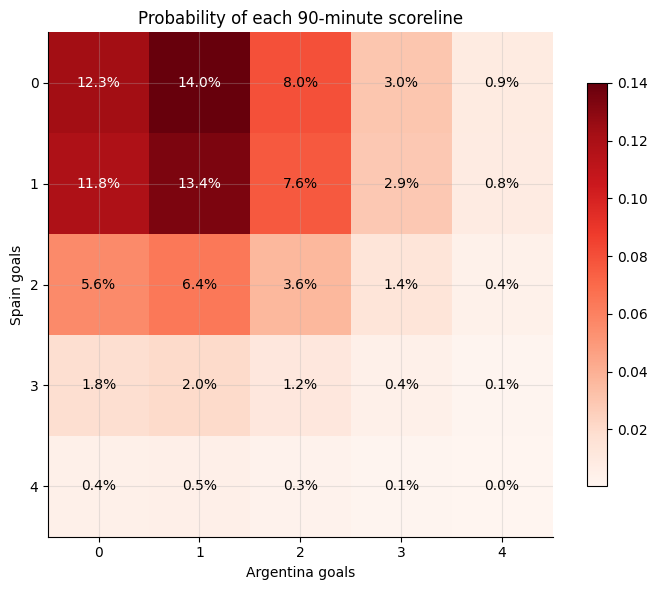

In [6]:
# Most likely 90-minute scorelines
from scipy.stats import poisson as poisson_dist
MAX_G = 7
ps = poisson_dist.pmf(np.arange(MAX_G + 1), lam_spain)
pa = poisson_dist.pmf(np.arange(MAX_G + 1), lam_arg)
matrix = np.outer(ps, pa)  # rows = Spain goals, cols = Argentina goals

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(matrix[:5, :5], cmap='Reds')
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xlabel('Argentina goals'); ax.set_ylabel('Spain goals')
ax.set_title('Probability of each 90-minute scoreline')
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{matrix[i, j]:.1%}', ha='center', va='center',
                color='white' if matrix[i, j] > matrix.max() * 0.6 else 'black')
fig.colorbar(im, shrink=0.8)
plt.tight_layout()

flat = [(i, j, matrix[i, j]) for i in range(MAX_G+1) for j in range(MAX_G+1)]
top = sorted(flat, key=lambda x: -x[2])[:5]
print('Most likely scorelines after 90 minutes:')
for i, j, p in top:
    print(f'  Spain {i}-{j} Argentina : {p:.1%}')

## Lens 3 — Machine learning

The gradient boosting model from notebook 02 outputs 90-minute probabilities (home win / draw / away win). Since the final can't end in a draw, we split the draw probability using the shootout-adjusted split (a slight simplification: some draws are resolved in extra time, where the teams are also closely matched).

In [7]:
gb = joblib.load('../models/gradient_boosting.joblib')
final_features = pd.read_csv('../data/final_features.csv')
proba = gb.predict_proba(final_features)[0]  # [home win, draw, away win]

print(f"90-minute probabilities — Spain {proba[0]:.1%} | Draw {proba[1]:.1%} | Argentina {proba[2]:.1%}")
p_ml_spain = proba[0] + proba[1] * p_pens_spain
print(f"ML — Spain lifts the trophy: {p_ml_spain:.1%}, Argentina: {1-p_ml_spain:.1%}")

90-minute probabilities — Spain 43.9% | Draw 20.3% | Argentina 35.9%
ML — Spain lifts the trophy: 52.6%, Argentina: 47.4%


## The ensemble verdict

Each lens has different blind spots: Elo knows long-run strength but not scorelines; Poisson knows goals but not opponent quality; ML knows patterns but inherits noise from features. Averaging them is a simple, robust ensemble.

                     Spain Argentina
Elo expectancy       53.9%     46.1%
Poisson Monte Carlo  43.7%     56.3%
Gradient boosting    52.6%     47.4%
ENSEMBLE             50.1%     49.9%



PREDICTED WINNER: Spain (50.1% vs 49.9%)


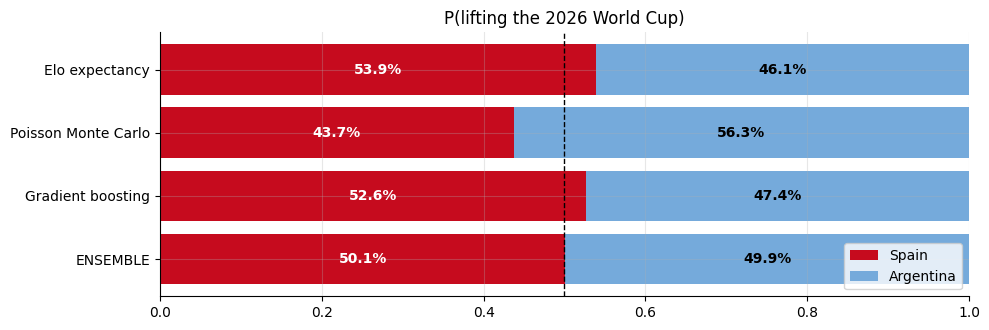

In [8]:
lenses = pd.DataFrame({
    'Spain': [p_elo_spain, p_mc_spain, p_ml_spain],
    'Argentina': [1-p_elo_spain, 1-p_mc_spain, 1-p_ml_spain]},
    index=['Elo expectancy', 'Poisson Monte Carlo', 'Gradient boosting'])
lenses.loc['ENSEMBLE'] = lenses.mean()
print((lenses * 100).round(1).astype(str) + '%')

p_final = lenses.loc['ENSEMBLE', 'Spain']

fig, ax = plt.subplots(figsize=(10, 3.4))
y = np.arange(len(lenses))
ax.barh(y, lenses['Spain'], color=COLORS[SPAIN], label='Spain')
ax.barh(y, lenses['Argentina'], left=lenses['Spain'], color=COLORS[ARG], label='Argentina')
ax.axvline(0.5, color='black', lw=1, ls='--')
ax.set_yticks(y, lenses.index)
ax.set_xlim(0, 1); ax.invert_yaxis()
for i, (s, a) in enumerate(zip(lenses['Spain'], lenses['Argentina'])):
    ax.text(s/2, i, f'{s:.1%}', ha='center', va='center', color='white', fontweight='bold')
    ax.text(s + a/2, i, f'{a:.1%}', ha='center', va='center', fontweight='bold')
ax.set_title('P(lifting the 2026 World Cup)')
ax.legend(loc='lower right')
plt.tight_layout()

winner = SPAIN if p_final >= 0.5 else ARG
print(f"\nPREDICTED WINNER: {winner} "
      f"({max(p_final, 1-p_final):.1%} vs {min(p_final, 1-p_final):.1%})")

## Conclusions & limitations

**The models agree this is one of the closest finals imaginable** — the ensemble sits near 50/50, which is itself an honest and defensible prediction between the world's #1 and #2 rated teams. Whichever side of 50% the ensemble lands on is the pick, but the margin is small.

Key drivers:

- Spain's tournament defence (1 goal conceded) pushes the Poisson model toward low-scoring outcomes
- Argentina's superior shootout record matters: a meaningful share of simulations reach penalties, where Argentina holds the edge
- The Elo ratings, built from 150 years of results, see the two sides as nearly equal

**Limitations (things I'd improve next):**

- Poisson strengths are not opponent-adjusted (a Dixon-Coles model would fix this)
- No player-level data: injuries, suspensions, or a suspended star striker are invisible to these models
- Head-to-head psychology, manager tactics, and rest days between matches are ignored
- The draw-resolution for the ML lens is a simplification of extra-time dynamics

**Possible extensions:** Dixon-Coles bivariate Poisson, betting-odds benchmark comparison, player-rating features, Bayesian updating during the tournament.